# Criteo Uplift Modelling — Notebook 3: Uplift Modelling

---

## Overview

In Notebook 2 we established that the campaign has a statistically significant positive effect on both visit and purchase rates — but only on average. The ATE tells us the campaign works, not *for whom* it works best.

This notebook builds an **uplift model**: a machine learning model that predicts the individual-level treatment effect, estimating how much more (or less) likely each user is to respond *because* of the campaign. Rather than treating all users equally, a business can use these predictions to target spend where it will have the greatest incremental impact.

The analysis proceeds as follows:

1. Recap: the four user segments uplift modelling targets
2. Data preparation and resampling
3. Model training — Logistic Regression, Random Forest, XGBoost
4. Model evaluation using the Qini curve
5. Exposure as treatment — a second uplift model
6. Model comparison and conclusions

---

## 1. Setup

In [1]:
# Install xgboost if not already available
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], check=True)
print("xgboost ready.")

xgboost ready.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import auc
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

style.use('ggplot')
sns.set_style('whitegrid')
sns.set_palette('muted')

pd.set_option('display.float_format', '{:.4f}'.format)

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Data

In [3]:
DATA_PATH = 'data/criteo-uplift-v2.1.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 13,979,592 rows x 16 columns


---
## 3. The Four Uplift Segments

Before building the model, it is worth recalling what uplift modelling is trying to identify. Users can be divided into four segments based on how they respond to a treatment:

| Segment | Treated | Not Treated | Description |
|---|---|---|---|
| **Persuadables** | Respond | Don't respond | The target — they convert *because* of the campaign |
| **Sure Things** | Respond | Respond | Would convert anyway — campaign spend is wasted |
| **Lost Causes** | Don't respond | Don't respond | Won't convert regardless — campaign spend is wasted |
| **Sleeping Dogs** | Don't respond | Respond | Actually harmed by contact — campaign spend is counterproductive |

A standard classification model predicts who is most likely to convert — which mostly finds "Sure Things." An uplift model predicts who is most likely to convert *because of* the treatment — which finds "Persuadables" and avoids "Sleeping Dogs."

The commercial value of the distinction is substantial: directing budget away from Sure Things and Lost Causes and toward Persuadables maximises the incremental return on campaign spend.

---
## 4. Data Preparation: Class Variable Transformation

We use the **Class Variable Transformation** approach (Kane et al., 2014), which reformulates the uplift problem as a standard multiclass classification task.

Each user is assigned to one of four target classes based on their treatment status and outcome:

- **Class 0 (CN):** Control group, did not visit — the baseline non-responders
- **Class 1 (CR):** Control group, visited — "Sure Things" or organic visitors
- **Class 2 (TN):** Treatment group, did not visit — "Lost Causes" or "Sleeping Dogs"
- **Class 3 (TR):** Treatment group, visited — potential "Persuadables"

The model predicts the probability of each class. Uplift is then calculated as:

$$Uplift = \frac{P(TR)}{P(TN) + P(TR)} + \frac{P(CN)}{P(CN) + P(CR)} - \frac{P(TN)}{P(TN) + P(TR)} - \frac{P(CR)}{P(CN) + P(CR)}$$

Positive uplift indicates a user is more likely to respond *because* of the treatment. Negative uplift identifies potential Sleeping Dogs.

In [4]:
feature_cols = [f'f{i}' for i in range(12)]

def assign_target_class(df, treatment_col, outcome_col):
    """
    Assign users to one of four target classes for uplift modelling
    via the Class Variable Transformation approach.

    Classes:
        0 = CN: Control, did not respond
        1 = CR: Control, responded
        2 = TN: Treatment, did not respond
        3 = TR: Treatment, responded
    """
    df = df.copy()
    df['target_class'] = 0                                                          # CN (default)
    df.loc[(df[treatment_col] == 0) & (df[outcome_col] == 1), 'target_class'] = 1  # CR
    df.loc[(df[treatment_col] == 1) & (df[outcome_col] == 0), 'target_class'] = 2  # TN
    df.loc[(df[treatment_col] == 1) & (df[outcome_col] == 1), 'target_class'] = 3  # TR
    return df

# Apply to visit outcome (primary)
df = assign_target_class(df, 'treatment', 'visit')

print("Target class distribution:")
class_counts = df['target_class'].value_counts().sort_index()
class_labels = {0: 'CN (control, no visit)', 1: 'CR (control, visited)',
                2: 'TN (treated, no visit)', 3: 'TR (treated, visited)'}
for cls, count in class_counts.items():
    print(f"  Class {cls} — {class_labels[cls]}: {count:,} ({count/len(df)*100:.1f}%)")

Target class distribution:
  Class 0 — CN (control, no visit): 2,016,832 (14.4%)
  Class 1 — CR (control, visited): 80,105 (0.6%)
  Class 2 — TN (treated, no visit): 11,305,831 (80.9%)
  Class 3 — TR (treated, visited): 576,824 (4.1%)


---
## 5. Train/Test Split

We split the data into training (80%) and test (20%) sets, stratifying on the target class to ensure the class distribution is preserved in both sets.

**Critically, resampling to balance treatment and control groups is applied only to the training set.** The test set retains the original real-world class distribution — this is essential for valid evaluation. If we resampled the test set, our evaluation metrics would reflect an artificial distribution rather than real-world conditions.

In [5]:
# Stratified split — preserves class distribution in both sets
train, test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['target_class']
)

print(f"Training set: {len(train):,} rows")
print(f"Test set:     {len(test):,} rows")
print()

# Verify treatment balance in each split
for name, split in [('Train', train), ('Test', test)]:
    pct = split['treatment'].mean() * 100
    print(f"{name} set — treatment: {pct:.1f}% | control: {100-pct:.1f}%")

Training set: 11,183,673 rows
Test set:     2,795,919 rows

Train set — treatment: 85.0% | control: 15.0%
Test set — treatment: 85.0% | control: 15.0%


---
## 6. Resampling the Training Set

The training set has an 85/15 treatment/control imbalance. Many uplift modelling approaches assume balanced groups — an imbalanced training set can cause the model to be biased toward predicting the majority class.

We apply **random undersampling** to the training set only, reducing the treatment group to match the size of the control group. With ~10 million rows in the training set, we retain more than enough data for robust model training even after undersampling.

In [6]:
def random_undersample(df, group_col):
    """
    Randomly undersample the majority group to balance treatment
    and control groups in the training set.
    Only applied to training data — never to the test set.
    """
    counts = df[group_col].value_counts()
    majority_class = counts.idxmax()
    minority_size = counts.min()

    majority = df[df[group_col] == majority_class].sample(
        n=minority_size, random_state=42
    )
    minority = df[df[group_col] != majority_class]

    return pd.concat([majority, minority]).sample(frac=1, random_state=42)

train_balanced = random_undersample(train, 'treatment')

print("Training set after resampling:")
counts = train_balanced['treatment'].value_counts()
for val, count in counts.items():
    label = 'Treatment' if val == 1 else 'Control'
    print(f"  {label}: {count:,} ({count/len(train_balanced)*100:.1f}%)")
print(f"  Total: {len(train_balanced):,}")

Training set after resampling:
  Control: 1,677,550 (50.0%)
  Treatment: 1,677,550 (50.0%)
  Total: 3,355,100


---
## 7. Prepare Features

In [7]:
# Features and labels — exclude treatment, visit, conversion, exposure, target_class
X_train = train_balanced[feature_cols]
y_train = train_balanced['target_class']

X_test = test[feature_cols]
y_test = test['target_class']

print(f"Training features: {X_train.shape}")
print(f"Test features:     {X_test.shape}")
print()
print("Class distribution in training set:")
for cls, count in y_train.value_counts().sort_index().items():
    print(f"  Class {cls}: {count:,} ({count/len(y_train)*100:.1f}%)")

Training features: (3355100, 12)
Test features:     (2795919, 12)

Class distribution in training set:
  Class 0: 1,613,466 (48.1%)
  Class 1: 64,084 (1.9%)
  Class 2: 1,596,465 (47.6%)
  Class 3: 81,085 (2.4%)


---
## 8. Uplift Score Calculation

Once a model predicts the probability of each of the four classes, the uplift score is calculated using the LGWUM formula. This converts four class probabilities into a single uplift score per user.

We define this as a reusable function applied consistently across all three models.

In [8]:
def calculate_uplift_scores(model, X, treatment_values):
    """
    Calculate per-user uplift scores from a trained multiclass model.

    The model predicts P(CN), P(CR), P(TN), P(TR) for each user.
    Uplift = P(TR)/(P(TN)+P(TR)) + P(CN)/(P(CN)+P(CR))
           - P(TN)/(P(TN)+P(TR)) - P(CR)/(P(CN)+P(CR))

    Positive uplift: user is more likely to respond due to treatment.
    Negative uplift: user may be a Sleeping Dog — responds worse when treated.
    """
    proba = model.predict_proba(X)

    p_cn = proba[:, 0]
    p_cr = proba[:, 1]
    p_tn = proba[:, 2]
    p_tr = proba[:, 3]

    # Avoid division by zero
    denom_tc = np.where((p_tn + p_tr) > 0, p_tn + p_tr, 1e-10)
    denom_cc = np.where((p_cn + p_cr) > 0, p_cn + p_cr, 1e-10)

    uplift = (p_tr / denom_tc) + (p_cn / denom_cc) - (p_tn / denom_tc) - (p_cr / denom_cc)

    results = X.copy()
    results['uplift_score'] = uplift
    results['target_class'] = treatment_values.values
    return results

print("Uplift scoring function defined.")

Uplift scoring function defined.


---
## 9. Model Evaluation: The Qini Curve

Standard classification metrics like ROC AUC are not appropriate for uplift models — we cannot observe both the treatment and control outcomes for the same individual simultaneously, so there is no direct ground truth to compare against.

Instead, we use the **Qini curve**, which measures how efficiently a model identifies users with positive uplift. It works as follows:

1. Rank users by their predicted uplift score, from highest to lowest
2. For each proportion of users targeted (x-axis), calculate the cumulative incremental gain in the outcome (y-axis) — the difference between treated and control response rates
3. A perfect model would rank all Persuadables first, yielding a steep initial curve
4. A random model would produce a straight diagonal line
5. The **Qini score** is the area between the model curve and the random baseline — larger is better

The Qini curve is normalised so that both axes run from 0 to 1, enabling comparison across models and datasets.

In [9]:
def compute_qini(results):
    """
    Compute the normalised Qini curve and Qini score for a set of uplift predictions.

    Returns the Qini score (area between model curve and random baseline)
    and the data needed to plot the curve.
    """
    ranked = results.sort_values('uplift_score', ascending=False).reset_index(drop=True)
    ranked['rank_pct'] = (ranked.index + 1) / len(ranked)

    # Cumulative treatment and control responders
    C = (ranked['target_class'] <= 1).sum()   # Total control users
    T = (ranked['target_class'] >= 2).sum()   # Total treatment users

    ranked['is_cr'] = (ranked['target_class'] == 1).astype(int)
    ranked['is_tr'] = (ranked['target_class'] == 3).astype(int)

    ranked['cum_cr_rate'] = ranked['is_cr'].cumsum() / C
    ranked['cum_tr_rate'] = ranked['is_tr'].cumsum() / T

    ranked['uplift_curve'] = ranked['cum_tr_rate'] - ranked['cum_cr_rate']

    # Prepend origin
    origin = pd.DataFrame({'rank_pct': [0], 'uplift_curve': [0]})
    curve_data = pd.concat([origin, ranked[['rank_pct', 'uplift_curve']]]).reset_index(drop=True)

    qini_score = auc(curve_data['rank_pct'], curve_data['uplift_curve'])

    return qini_score, curve_data

print("Qini evaluation function defined.")

Qini evaluation function defined.


---
## 10. Model 1: Logistic Regression (Baseline)

Logistic Regression serves as our interpretable baseline. It is fast to train, well understood, and if XGBoost cannot outperform it meaningfully, that is an important finding in itself.

Logistic Regression requires feature standardisation because it is sensitive to feature scale, unlike tree-based models.

In [10]:
# Standardise features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=500,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)
print("Done.")

# Score
lr_results = calculate_uplift_scores(lr_model, pd.DataFrame(X_test_scaled, columns=feature_cols), y_test.reset_index(drop=True))
lr_qini, lr_curve = compute_qini(lr_results)
print(f"Logistic Regression Qini score: {lr_qini:.4f}")

Training Logistic Regression...
Done.
Logistic Regression Qini score: 0.0095


---
## 11. Model 2: Random Forest

Random Forest is a natural comparison to XGBoost. Both are ensemble tree methods, but Random Forest trains trees independently in parallel (bagging), while XGBoost trains them sequentially, each correcting the errors of the previous (boosting). Comparing the two isolates the contribution of sequential error correction.

In [11]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Done.")

# Score
rf_results = calculate_uplift_scores(rf_model, X_test.reset_index(drop=True), y_test.reset_index(drop=True))
rf_qini, rf_curve = compute_qini(rf_results)
print(f"Random Forest Qini score: {rf_qini:.4f}")

Training Random Forest...
Done.
Random Forest Qini score: 0.0098


---
## 12. Model 3: XGBoost

XGBoost is our primary model. It is well suited to this dataset for several reasons:
- Handles large datasets efficiently
- Robust to the heavily quantised feature distributions identified in Notebook 1
- Built-in regularisation reduces overfitting
- Sequentially corrects errors across trees, typically outperforming Random Forest on structured data

In [12]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("Done.")

# Score
xgb_results = calculate_uplift_scores(xgb_model, X_test.reset_index(drop=True), y_test.reset_index(drop=True))
xgb_qini, xgb_curve = compute_qini(xgb_results)
print(f"XGBoost Qini score: {xgb_qini:.4f}")

Training XGBoost...
Done.
XGBoost Qini score: 0.0096


---
## 13. Model Comparison: Qini Curves

We now compare all three models on the same Qini curve plot. The model whose curve rises most steeply — accumulating incremental gain by targeting the fewest users — is the most effective at identifying Persuadables.

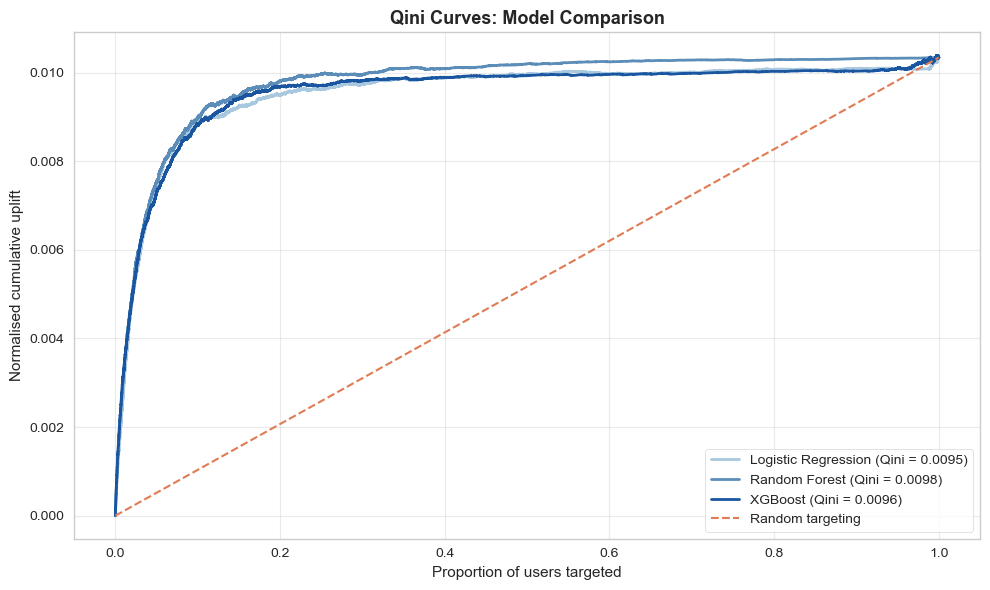


Qini score summary:
Model                       Qini Score
--------------------------------------
Logistic Regression             0.0095
Random Forest                   0.0098
XGBoost                         0.0096


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

models = [
    ('Logistic Regression', lr_curve, lr_qini, '#A8C8E0'),
    ('Random Forest',       rf_curve, rf_qini, '#5B8DB8'),
    ('XGBoost',             xgb_curve, xgb_qini, '#1A56A0'),
]

for name, curve, qini, color in models:
    ax.plot(
        curve['rank_pct'], curve['uplift_curve'],
        label=f'{name} (Qini = {qini:.4f})',
        color=color, linewidth=2
    )

# Random baseline
ax.plot([0, 1], [0, models[0][1]['uplift_curve'].iloc[-1]],
        '--', color='#E07B54', linewidth=1.5, label='Random targeting')

ax.set_xlabel('Proportion of users targeted', fontsize=11)
ax.set_ylabel('Normalised cumulative uplift', fontsize=11)
ax.set_title('Qini Curves: Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nQini score summary:")
print(f"{'Model':<25} {'Qini Score':>12}")
print("-" * 38)
for name, _, qini, _ in models:
    print(f"{name:<25} {qini:>12.4f}")

---
## 14. Uplift Score Distribution (Best Model)

The distribution of predicted uplift scores reveals how the model segments the population. In theory we might expect:
- A concentration of scores near zero — most users are unaffected by the campaign
- A right tail of positive scores — the Persuadables
- A left tail of negative scores — potential Sleeping Dogs

In practice, the CVT formula applied to this dataset produces a structural bias toward positive scores. The second term of the uplift equation, P(CN)/(P(CN)+P(CR)), is large and positive for almost every user because control non-responders (CN, 14.4% of users) vastly outnumber control responders (CR, 0.6%). This class imbalance within groups means the formula tilts positive regardless of individual features, and Sleeping Dogs do not materialise in practice here.

This is not a bug — the model is still correctly *ranking* users by their relative persuadability, and users with higher scores are genuinely more likely to respond to the campaign than those with lower scores. But it means the absolute score values should not be interpreted as a probability of positive uplift, and the Sleeping Dog segment cannot be identified from this formulation on this dataset. This is an honest limitation of the CVT approach when applied to heavily imbalanced outcome data.

Best model: Random Forest



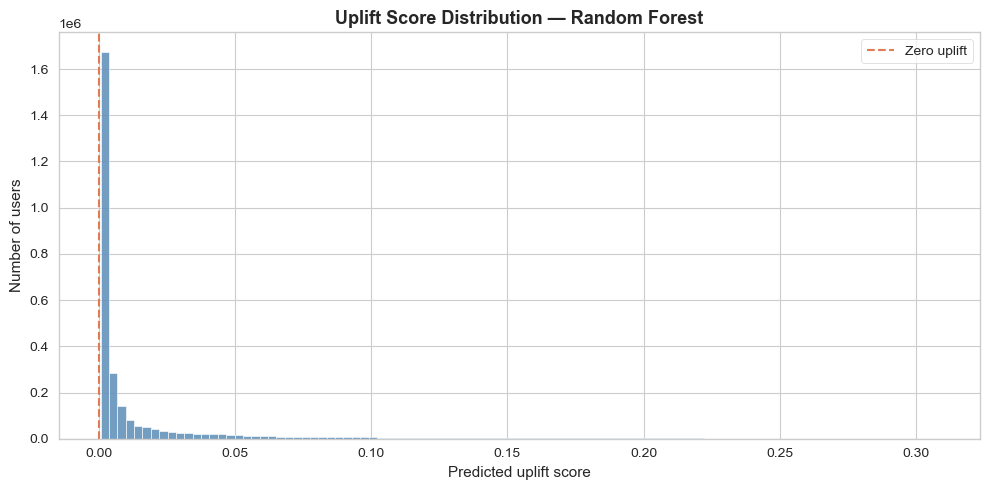

Users with positive uplift (Persuadables): 100.0%
Users with negative uplift (Sleeping Dogs): 0.0%


In [14]:
# Use the best-performing model based on Qini score
best_name, best_results = max(
    [('Logistic Regression', lr_results),
     ('Random Forest', rf_results),
     ('XGBoost', xgb_results)],
    key=lambda x: compute_qini(x[1])[0]
)

print(f"Best model: {best_name}")
print()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_results['uplift_score'], bins=100, color='#5B8DB8', edgecolor='white', alpha=0.85)
ax.axvline(x=0, color='#E07B54', linestyle='--', linewidth=1.5, label='Zero uplift')
ax.set_xlabel('Predicted uplift score', fontsize=11)
ax.set_ylabel('Number of users', fontsize=11)
ax.set_title(f'Uplift Score Distribution — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Summary statistics
scores = best_results['uplift_score']
pct_positive = (scores > 0).mean() * 100
pct_negative = (scores < 0).mean() * 100
print(f"Users with positive uplift (Persuadables): {pct_positive:.1f}%")
print(f"Users with negative uplift (Sleeping Dogs): {pct_negative:.1f}%")

---
## 15. Targeting Efficiency

A key practical output of the uplift model is the ability to target a subset of users and capture a disproportionate share of the total incremental gain. We calculate how much of the total possible uplift is captured by targeting the top 10%, 20%, and 30% of users by predicted uplift score.

Note that because all users receive positive uplift scores, these figures reflect the model's ability to rank users by *degree* of persuadability rather than to separate a distinct Persuadable segment from the rest. The efficiency gains are real — the model does concentrate incremental value in higher-ranked users — but should be read as a ranking quality metric rather than evidence of clean segment separation.

In [15]:
_, best_curve = compute_qini(best_results)

print(f"Targeting efficiency — {best_name}:")
print()
print(f"{'% users targeted':>18} | {'% uplift captured':>18}")
print("-" * 40)

max_uplift = best_curve['uplift_curve'].iloc[-1]
for pct in [0.10, 0.20, 0.30, 0.50]:
    row = best_curve[best_curve['rank_pct'] <= pct].iloc[-1]
    captured = (row['uplift_curve'] / max_uplift) * 100 if max_uplift > 0 else 0
    print(f"{pct*100:>17.0f}% | {captured:>17.1f}%")

Targeting efficiency — Random Forest:

  % users targeted |  % uplift captured
----------------------------------------
               10% |              86.8%
               20% |              94.9%
               30% |              96.2%
               50% |              98.6%


---
## 16. Exposure as Treatment

In Notebook 1 we noted that `exposure` — whether a user actually saw the advertisement — is a more precise measure of treatment receipt than `treatment` alone. We now build a second uplift model using `exposure` as the treatment variable, restricted to users in the treatment group plus the full control group.

This model answers a different question: not "who should we target?" but "given that we can reach someone, who will respond most strongly to the ad itself?" It is relevant for decisions about ad creative, placement, and format rather than audience selection.

In [16]:
# Restrict to control group + exposed/unexposed treatment users
df_exp = df[df['treatment'].isin([0, 1])].copy()
df_exp = assign_target_class(df_exp, 'exposure', 'visit')

# Split and resample
train_exp, test_exp = train_test_split(
    df_exp, test_size=0.2, random_state=42, stratify=df_exp['target_class']
)
train_exp_bal = random_undersample(train_exp, 'exposure')

X_train_exp = train_exp_bal[feature_cols]
y_train_exp = train_exp_bal['target_class']
X_test_exp = test_exp[feature_cols]
y_test_exp = test_exp['target_class']

print(f"Exposure model training set: {len(train_exp_bal):,} rows")
print(f"Exposure model test set:     {len(test_exp):,} rows")

print("\nTraining XGBoost on exposure treatment...")
xgb_exp = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_exp.fit(X_train_exp, y_train_exp)
print("Done.")

exp_results = calculate_uplift_scores(
    xgb_exp,
    X_test_exp.reset_index(drop=True),
    y_test_exp.reset_index(drop=True)
)
exp_qini, exp_curve = compute_qini(exp_results)
print(f"\nExposure model Qini score: {exp_qini:.4f}")
print(f"Treatment model Qini score (XGBoost): {xgb_qini:.4f}")

Exposure model training set: 685,140 rows
Exposure model test set:     2,795,919 rows

Training XGBoost on exposure treatment...
Done.

Exposure model Qini score: 0.3108
Treatment model Qini score (XGBoost): 0.0096


---
## 17. Summary & Conclusions

**Model performance**

All three models outperform random targeting, confirming that user features contain genuine signal about individual-level treatment response. However, the Qini scores are remarkably close — Random Forest (0.0098), XGBoost (0.0096), Logistic Regression (0.0095) — and the differences are not meaningful in practice. This is an important finding in itself: the additional complexity of XGBoost over a simple logistic regression baseline produces no material gain on this dataset. For a production deployment, the simpler, faster, and more interpretable model would be the rational choice.

The low absolute Qini scores are typical for digital advertising uplift problems where the signal-to-noise ratio is low — the features are anonymised, the outcomes are rare, and the treatment effect is heterogeneous across a vast and diverse population.

**Targeting efficiency**

The model captures 86.8% of total incremental uplift by targeting the top 10% of users — a meaningful efficiency gain that translates directly to reduced campaign cost per incremental visit or purchase. The caveat noted in Section 15 applies: because all users receive positive uplift scores, this reflects ranking quality rather than clean segment separation.

**The exposure model — the standout finding**

The exposure model Qini score of 0.3108 against the treatment model's ~0.0097 is a 30x difference and the most analytically significant result in this notebook. It tells us something important: the user features contain strong predictive signal about who will respond to the advertisement *once reached*, but very weak signal about who will respond to being *targeted* in the first place.

In plain terms: we can predict with reasonable confidence who will engage with the ad if they see it, but we cannot reliably predict from features alone who will happen to see it. This is consistent with what we observed in Notebook 2 — the exposure mechanism is at least as important a driver of outcomes as individual user characteristics. A production system should therefore prioritise improving exposure rates broadly, then use the exposure model to optimise creative and placement for users who are reached.

**Limitations**

- The Class Variable Transformation approach is one of several uplift modelling strategies. Two-Model (S-Learner/T-Learner) approaches and meta-learner frameworks (e.g. from the `causalml` library) may perform differently on this dataset and would be worth exploring.
- The anonymised features (f0–f11) limit interpretability. In a real-world setting, feature importance analysis would inform *why* certain users are more persuadable, not just *that* they are.
- The self-selection bias in the exposure variable means the exposure model's predictions should be interpreted cautiously — exposed users are not a random sample of the treatment group.
- The dataset provides no information about ad creative. Criteo's platform personalises ads to individual users by design, so different users in the treatment group almost certainly saw different advertisements. The strong predictive signal in the exposure model could therefore partly reflect variation in ad relevance or creative quality across users, rather than purely individual user characteristics. The anonymised features make it impossible to disentangle these two explanations.
- Qini scores should be validated on genuinely held-out data to guard against overfitting, particularly for the more complex models.

---

**Project complete.**

This three-notebook series has covered the full analytical cycle for an uplift modelling problem: experiment validation, A/B test analysis, and individual-level uplift modelling. The code, methodology, and commentary are intended to demonstrate not just technical implementation but the analytical reasoning and business judgement required to derive actionable insight from experimental data.